In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

mpl.rcParams.update(
    {
        "text.usetex": False,
        "axes.labelsize": 20,
        "figure.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "figure.constrained_layout.wspace": 0,
        "figure.constrained_layout.hspace": 0,
        "figure.constrained_layout.h_pad": 0,
        "figure.constrained_layout.w_pad": 0,
        "axes.linewidth": 1.2,
    }
)

import jax
import jax.numpy as jnp
from jax import flatten_util

jax.config.update("jax_enable_x64", True)

## Kernel Approximations for Convolved Transfer Functions

This notebook studies quasiseparable approximations to dense convolved kernels.

It shows how to:

1. build dense convolved kernels from transfer functions,
2. approximate those kernels with fixed-basis `SHOSeries` models, and
3. fit a **quasiseparable wrapper kernel** whose free parameters are the physical unconvolved-kernel and transfer-function parameters, while the SHO-series approximation is rebuilt internally at each likelihood evaluation.

The final section focuses on a top-hat transfer function and uses the fast `UniVarModel` machinery with a quasiseparable surrogate, rather than fitting the dense `ConvolvedKernel` directly.


In [2]:
import equinox as eqx
from scipy.optimize import minimize, nnls

from eztaox.kernels.eqx_utils import find_param_by_name
from eztaox.kernels.quasisep import Exp, Quasisep, SHO
from eztaox.kernels.transfer_function import (
    ConvolvedKernel,
    CausalGaussianTransferFunction,
    TransferFunction,
)
from eztaox.models import UniVarModel
from eztaox.simulator import UniVarSim
from eztaox.ts_utils import add_noise

In [3]:
class CausalTopHatTransferFunction(TransferFunction):
    """A normalized causal top-hat transfer function."""

    def evaluate(self, X1, X2):
        dt = X2 - X1 - self.shift
        half_width = self.width / 2.0
        inside = (dt >= -half_width) & (dt <= half_width)
        return jnp.where(inside, 1.0 / jnp.maximum(self.width, 1e-12), 0.0)

### 1. Dense convolved kernels

We will compare approximations for two transfer functions applied to the same DRW/OU base kernel:

- a causal Gaussian
- a causal top-hat


In [4]:
base_kernel = Exp(scale=80.0, sigma=0.2)
gaussian_tf = CausalGaussianTransferFunction(width=80.0, shift=30.0)
tophat_tf = CausalTopHatTransferFunction(width=80.0, shift=30.0)

convolved_kernel = ConvolvedKernel(
    base_kernel=base_kernel,
    transfer_function=gaussian_tf,
    n_grid=2048,
)
convolved_kernel_tophat = ConvolvedKernel(
    base_kernel=base_kernel,
    transfer_function=tophat_tf,
    n_grid=2048,
)

tau_grid = jnp.linspace(0.0, 300.0, 600)
k_base = jax.vmap(lambda tau: base_kernel.evaluate(0.0, tau))(tau_grid)
k_conv = jax.vmap(lambda tau: convolved_kernel.evaluate(0.0, tau))(tau_grid)
k_conv_tophat = jax.vmap(lambda tau: convolved_kernel_tophat.evaluate(0.0, tau))(
    tau_grid
)

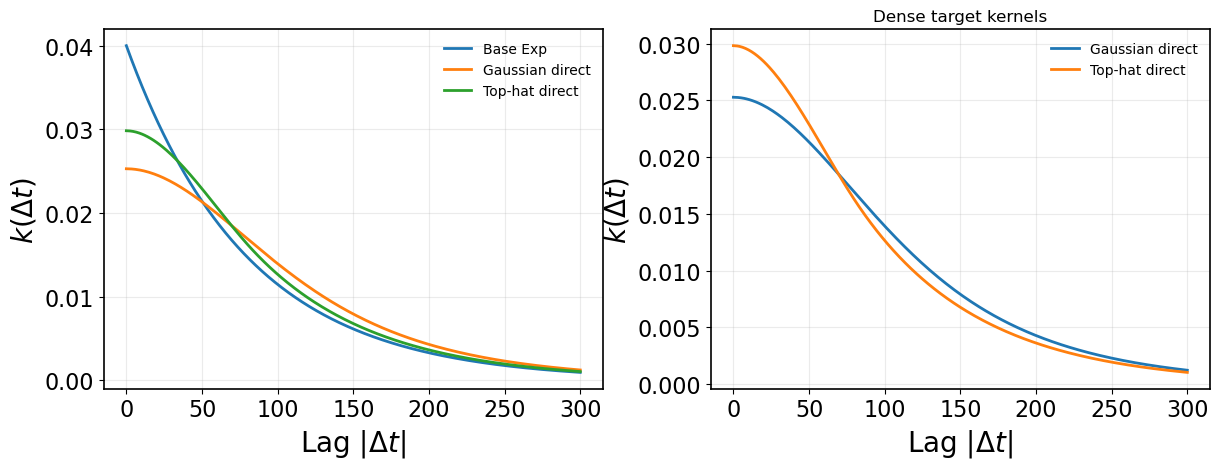

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].plot(np.asarray(tau_grid), np.asarray(k_base), label="Base Exp", lw=2)
axes[0].plot(np.asarray(tau_grid), np.asarray(k_conv), label="Gaussian direct", lw=2)
axes[0].plot(
    np.asarray(tau_grid), np.asarray(k_conv_tophat), label="Top-hat direct", lw=2
)
axes[0].set_xlabel(r"Lag $|\Delta t|$")
axes[0].set_ylabel(r"$k(\Delta t)$")
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)

axes[1].plot(np.asarray(tau_grid), np.asarray(k_conv), label="Gaussian direct", lw=2)
axes[1].plot(
    np.asarray(tau_grid), np.asarray(k_conv_tophat), label="Top-hat direct", lw=2
)
axes[1].set_xlabel(r"Lag $|\Delta t|$")
axes[1].set_ylabel(r"$k(\Delta t)$")
axes[1].set_title("Dense target kernels")
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False)

In [6]:
def stable_sho_cov(tau, omega, q, sigma=1.0):
    tau = jnp.asarray(tau)
    f = jnp.sqrt(jnp.maximum(1.0 - 4.0 * q**2, 1e-12))
    lam_slow = omega * (1.0 - f) / (2.0 * q)
    lam_fast = omega * (1.0 + f) / (2.0 * q)
    w_slow = 0.5 * (1.0 + 1.0 / f)
    w_fast = 0.5 * (1.0 - 1.0 / f)
    return sigma**2 * (
        w_slow * jnp.exp(-lam_slow * tau) + w_fast * jnp.exp(-lam_fast * tau)
    )


class SHOSeries(Quasisep):
    """Nonnegative mixture of fixed SHO atoms fit in the time domain."""

    omegas: jax.Array
    qualities: jax.Array
    weights: jax.Array

    @classmethod
    def from_kernel(
        cls,
        kernel,
        n_omega: int = 4,
        q_grid=(0.08, 0.22, 0.45),
        n_fit: int = 96,
        tau_max: float | None = None,
        scale_min_ratio: float = 0.05,
        scale_max_ratio: float = 2.25,
        weight_floor_ratio: float = 1e-3,
        zero_lag_boost: float = 20.0,
    ):
        kernel_scales = find_param_by_name(kernel, "scale")
        if kernel_scales is None:
            raise ValueError("Kernel must have a 'scale' parameter for auto placement.")

        base_scale = float(sum(kernel_scales) / len(kernel_scales))
        if tau_max is None:
            tau_max = scale_max_ratio * base_scale

        tau_min = max(scale_min_ratio * base_scale * 1e-2, 1e-6)
        tau_fit = np.concatenate([[0.0], np.geomspace(tau_min, tau_max, n_fit - 1)])
        tau_basis = np.geomspace(
            max(scale_min_ratio * base_scale, 1e-6),
            max(scale_max_ratio * base_scale, scale_min_ratio * base_scale * 1.01),
            n_omega,
        )
        omegas = 1.0 / tau_basis
        qualities = np.asarray(q_grid, dtype=float)

        tau_fit_jax = jnp.asarray(tau_fit)
        k_fit = np.asarray(
            jax.vmap(lambda tau: kernel.evaluate(jnp.array(0.0), tau))(tau_fit_jax)
        )

        atoms = [(omega, q) for q in qualities for omega in omegas]
        A = np.column_stack(
            [
                np.asarray(stable_sho_cov(tau_fit_jax, omega, q, sigma=1.0))
                for omega, q in atoms
            ]
        )

        k0 = float(k_fit[0])
        sigma_w = np.maximum(np.abs(k_fit), weight_floor_ratio * max(k0, 1e-12))
        sigma_w[0] /= zero_lag_boost
        Aw = A / sigma_w[:, None]
        bw = k_fit / sigma_w
        weights, _ = nnls(Aw, bw)

        wsum = weights.sum()
        if wsum > 0:
            weights *= k0 / wsum

        omega_arr = np.asarray([omega for omega, _ in atoms], dtype=float)
        q_arr = np.asarray([q for _, q in atoms], dtype=float)
        return cls(
            omegas=jnp.asarray(omega_arr),
            qualities=jnp.asarray(q_arr),
            weights=jnp.asarray(weights),
        )

    def _atoms(self):
        return [
            SHO(omega=self.omegas[i], quality=self.qualities[i], sigma=1.0)
            for i in range(self.omegas.shape[0])
        ]

    def coord_to_sortable(self, X):
        return X

    def design_matrix(self):
        atoms = self._atoms()
        return jax.scipy.linalg.block_diag(*[atom.design_matrix() for atom in atoms])

    def stationary_covariance(self):
        atoms = self._atoms()
        return jax.scipy.linalg.block_diag(
            *[
                self.weights[i] * atom.stationary_covariance()
                for i, atom in enumerate(atoms)
            ]
        )

    def observation_model(self, X):
        atoms = self._atoms()
        return jnp.concatenate([atom.observation_model(X) for atom in atoms])

    def transition_matrix(self, X1, X2):
        atoms = self._atoms()
        return jax.scipy.linalg.block_diag(
            *[atom.transition_matrix(X1, X2) for atom in atoms]
        )

    def power(self, f, df=None):
        del df
        out = 0.0
        for i, atom in enumerate(self._atoms()):
            out = out + self.weights[i] * atom.power(f)
        return out


class ConvolvedTopHatSHOWrapper(Quasisep):
    """Top-hat convolved kernel with a hybrid fixed-basis SHO approximation."""

    base_scale: float
    base_sigma: float
    width: float
    shift: float
    weight_multipliers: jax.Array
    omegas: tuple = eqx.field(static=True)
    qualities: tuple = eqx.field(static=True)
    tau_fit: tuple = eqx.field(static=True)
    basis_matrix: tuple = eqx.field(static=True)
    n_grid: int = eqx.field(static=True)
    weight_floor_ratio: float = eqx.field(static=True)
    zero_lag_boost: float = eqx.field(static=True)
    ridge: float = eqx.field(static=True)

    @classmethod
    def init(
        cls,
        base_scale,
        base_sigma,
        width,
        shift,
        tau_basis=np.geomspace(4.0, 180.0, 4),
        q_grid=(0.08, 0.22, 0.45),
        tau_fit=np.concatenate([[0.0], np.geomspace(0.15, 220.0, 95)]),
        n_grid=512,
        weight_floor_ratio=1e-3,
        zero_lag_boost=20.0,
        ridge=1e-5,
    ):
        atoms = [(omega, q) for q in q_grid for omega in 1.0 / np.asarray(tau_basis)]
        A = np.column_stack(
            [
                np.asarray(stable_sho_cov(jnp.asarray(tau_fit), omega, q, sigma=1.0))
                for omega, q in atoms
            ]
        )
        return cls(
            base_scale=float(base_scale),
            base_sigma=float(base_sigma),
            width=float(width),
            shift=float(shift),
            weight_multipliers=jnp.ones(len(atoms)),
            omegas=tuple(float(omega) for omega, _ in atoms),
            qualities=tuple(float(q) for _, q in atoms),
            tau_fit=tuple(float(x) for x in tau_fit),
            basis_matrix=tuple(tuple(float(v) for v in row) for row in A),
            n_grid=int(n_grid),
            weight_floor_ratio=float(weight_floor_ratio),
            zero_lag_boost=float(zero_lag_boost),
            ridge=float(ridge),
        )

    def dense_kernel(self):
        return ConvolvedKernel(
            base_kernel=Exp(scale=self.base_scale, sigma=self.base_sigma),
            transfer_function=CausalTopHatTransferFunction(
                width=self.width, shift=self.shift
            ),
            n_grid=self.n_grid,
        )

    def _projected_weights(self):
        tau_fit = jnp.asarray(self.tau_fit)
        dense_kernel = self.dense_kernel()
        k_fit = jax.vmap(lambda tau: dense_kernel.evaluate(jnp.array(0.0), tau))(
            tau_fit
        )
        k0 = k_fit[0]
        sigma_w = jnp.maximum(
            jnp.abs(k_fit), self.weight_floor_ratio * jnp.maximum(k0, 1e-12)
        )
        sigma_w = sigma_w.at[0].set(sigma_w[0] / self.zero_lag_boost)

        A = jnp.asarray(self.basis_matrix)
        Aw = A / sigma_w[:, None]
        bw = k_fit / sigma_w
        ata = Aw.T @ Aw + self.ridge * jnp.eye(Aw.shape[1])
        atb = Aw.T @ bw
        weights = jnp.linalg.solve(ata, atb)
        weights = jnp.clip(weights, 0.0)
        weights = weights * (k0 / jnp.maximum(jnp.sum(weights), 1e-12))
        return weights, k0

    def _weights(self):
        projected_weights, k0 = self._projected_weights()
        weights = projected_weights * self.weight_multipliers
        weights = weights * (k0 / jnp.maximum(jnp.sum(weights), 1e-12))
        return weights

    def _atoms(self):
        return [
            SHO(omega=self.omegas[i], quality=self.qualities[i], sigma=1.0)
            for i in range(len(self.omegas))
        ]

    def coord_to_sortable(self, X):
        return X

    def design_matrix(self):
        atoms = self._atoms()
        return jax.scipy.linalg.block_diag(*[atom.design_matrix() for atom in atoms])

    def stationary_covariance(self):
        atoms = self._atoms()
        weights = self._weights()
        return jax.scipy.linalg.block_diag(
            *[weights[i] * atom.stationary_covariance() for i, atom in enumerate(atoms)]
        )

    def observation_model(self, X):
        atoms = self._atoms()
        return jnp.concatenate([atom.observation_model(X) for atom in atoms])

    def transition_matrix(self, X1, X2):
        atoms = self._atoms()
        return jax.scipy.linalg.block_diag(
            *[atom.transition_matrix(X1, X2) for atom in atoms]
        )

    def power(self, f, df=None):
        del df
        weights = self._weights()
        out = 0.0
        for i, atom in enumerate(self._atoms()):
            out = out + weights[i] * atom.power(f)
        return out

In [7]:
def kernel_params(kernel):
    if hasattr(kernel, "base_kernel"):
        return {
            "scale": float(kernel.base_kernel.scale),
            "sigma": float(kernel.base_kernel.sigma),
            "width": float(kernel.transfer_function.width),
            "shift": float(kernel.transfer_function.shift),
        }
    return {
        "scale": float(kernel.base_scale),
        "sigma": float(kernel.base_sigma),
        "width": float(kernel.width),
        "shift": float(kernel.shift),
    }


def series_covariance(kernel, tau):
    weights = kernel._weights()
    out = 0.0
    for i, (omega, q) in enumerate(zip(kernel.omegas, kernel.qualities)):
        out = out + weights[i] * stable_sho_cov(tau, omega, q, sigma=1.0)
    return out

### 2. Gaussian transfer function: compare the dense kernel and `SHOSeries`


In [8]:
sho_series = SHOSeries.from_kernel(
    convolved_kernel,
    n_omega=4,
    q_grid=(0.08, 0.22, 0.45),
    n_fit=96,
    tau_max=float(tau_grid.max()),
    scale_min_ratio=0.05,
    scale_max_ratio=2.25,
)

k_sho = jax.vmap(lambda tau: sho_series.evaluate(0.0, tau))(tau_grid)

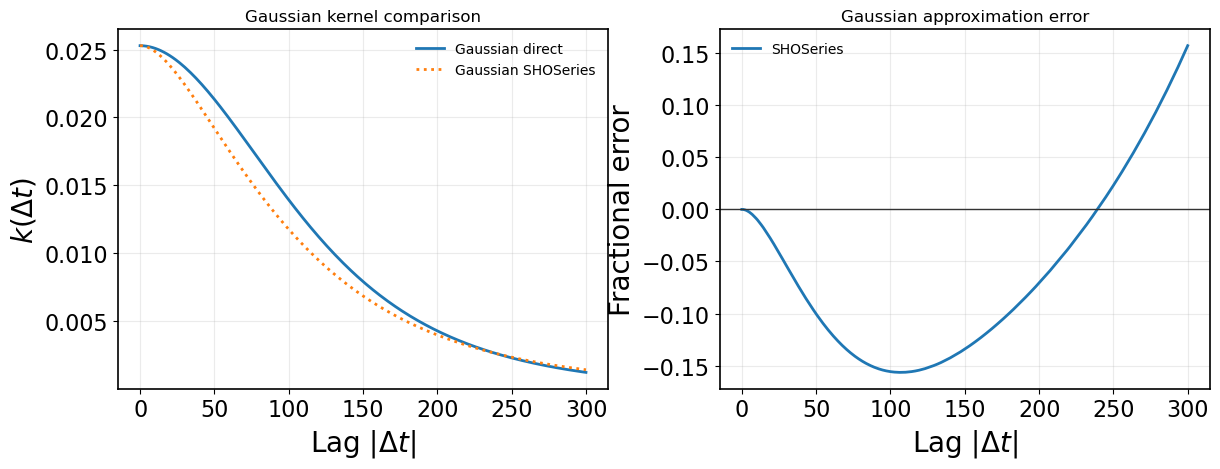

In [9]:
frac_err_sho = (k_sho - k_conv) / jnp.maximum(jnp.abs(k_conv), 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].plot(np.asarray(tau_grid), np.asarray(k_conv), label="Gaussian direct", lw=2)
axes[0].plot(
    np.asarray(tau_grid), np.asarray(k_sho), label="Gaussian SHOSeries", lw=2, ls=":"
)
axes[0].set_xlabel(r"Lag $|\Delta t|$")
axes[0].set_ylabel(r"$k(\Delta t)$")
axes[0].set_title("Gaussian kernel comparison")
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)

axes[1].plot(np.asarray(tau_grid), np.asarray(frac_err_sho), label="SHOSeries", lw=2)
axes[1].axhline(0.0, color="0.2", lw=1)
axes[1].set_xlabel(r"Lag $|\Delta t|$")
axes[1].set_ylabel("Fractional error")
axes[1].set_title("Gaussian approximation error")
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False)

### 3. Top-hat transfer function: compare the dense kernel and `SHOSeries`

This uses the same fixed SHO dictionary that will be used later in the wrapper fit.


In [10]:
sho_series_tophat = SHOSeries.from_kernel(
    convolved_kernel_tophat,
    n_omega=4,
    q_grid=(0.08, 0.22, 0.45),
    n_fit=96,
    tau_max=float(tau_grid.max()),
    scale_min_ratio=0.05,
    scale_max_ratio=2.25,
)

k_sho_tophat = jax.vmap(lambda tau: sho_series_tophat.evaluate(0.0, tau))(tau_grid)

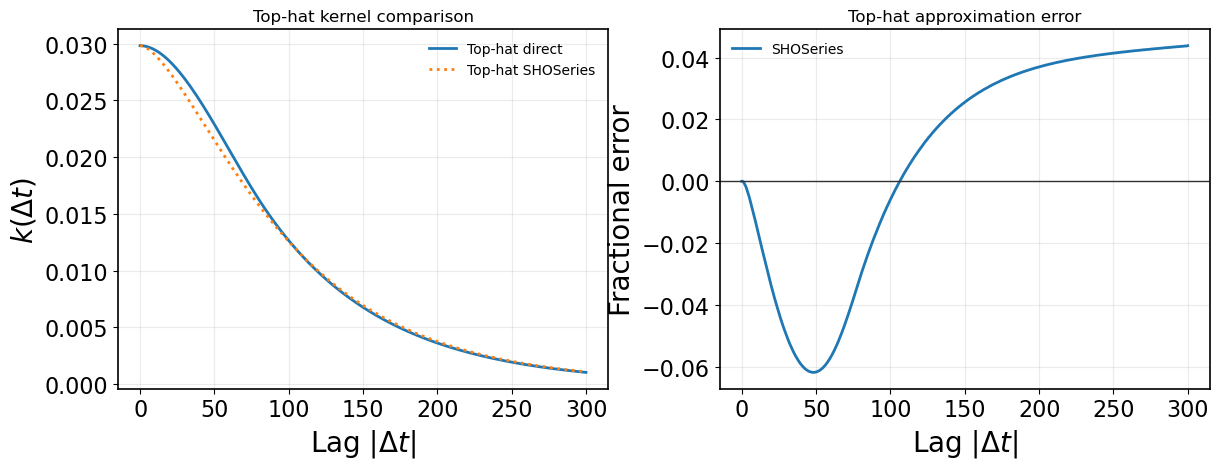

In [11]:
frac_err_sho_tophat = (k_sho_tophat - k_conv_tophat) / jnp.maximum(
    jnp.abs(k_conv_tophat), 1e-12
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].plot(
    np.asarray(tau_grid), np.asarray(k_conv_tophat), label="Top-hat direct", lw=2
)
axes[0].plot(
    np.asarray(tau_grid),
    np.asarray(k_sho_tophat),
    label="Top-hat SHOSeries",
    lw=2,
    ls=":",
)
axes[0].set_xlabel(r"Lag $|\Delta t|$")
axes[0].set_ylabel(r"$k(\Delta t)$")
axes[0].set_title("Top-hat kernel comparison")
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)

axes[1].plot(
    np.asarray(tau_grid), np.asarray(frac_err_sho_tophat), label="SHOSeries", lw=2
)
axes[1].axhline(0.0, color="0.2", lw=1)
axes[1].set_xlabel(r"Lag $|\Delta t|$")
axes[1].set_ylabel("Fractional error")
axes[1].set_title("Top-hat approximation error")
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False)

### 4. Fit a quasiseparable top-hat wrapper with physical kernel parameters

Instead of fitting the dense `ConvolvedKernel` directly, we now fit a notebook-local quasiseparable wrapper. Its free parameters are the physical unconvolved-kernel scale and amplitude together with the top-hat transfer-function width and shift. Internally, the wrapper rebuilds the top-hat convolution and then solves for the fixed-basis SHO mixture weights on each likelihood evaluation.

For this single-band example, the transfer-function shift is fixed at its true value because the autocovariance is much more sensitive to the transfer-function width than to a pure centroid shift.


In [12]:
true_wrapper = ConvolvedTopHatSHOWrapper.init(
    base_scale=80.0,
    base_sigma=0.2,
    width=60.0,
    shift=30.0,
)
fit_wrapper0 = ConvolvedTopHatSHOWrapper.init(
    base_scale=55.0,
    base_sigma=0.12,
    width=45.0,
    shift=30.0,
)

flat_true, _ = flatten_util.ravel_pytree(true_wrapper)
flat0, wrapper_unravel = flatten_util.ravel_pytree(fit_wrapper0)

sim = UniVarSim(
    true_wrapper,
    1.0,
    300.0,
    {"log_kernel_param": jnp.log(flat_true)},
    zero_mean=True,
)
sim_t = jnp.linspace(0.0, 300.0, 64)
t_obs, y_true = sim.fixed_input_fast(sim_t, jax.random.PRNGKey(12))
yerr = jnp.full_like(t_obs, 0.005)
y_obs = add_noise(y_true, yerr, jax.random.PRNGKey(13))

model = UniVarModel(t_obs, y_obs, yerr, fit_wrapper0, zero_mean=True)
fit_params0 = {"log_kernel_param": jnp.log(jnp.clip(flat0, 1e-12, None))}

print("Initial log probability:", float(model.log_prob(fit_params0)))
print("True physical parameters:", kernel_params(true_wrapper))
print("Initial physical parameters:", kernel_params(fit_wrapper0))

Initial log probability: 144.333692260073
True physical parameters: {'scale': 80.0, 'sigma': 0.2, 'width': 60.0, 'shift': 30.0}
Initial physical parameters: {'scale': 55.0, 'sigma': 0.12, 'width': 45.0, 'shift': 30.0}


In [13]:
def objective(log_param_np):
    x = jnp.asarray(log_param_np)
    lp = model.log_prob({"log_kernel_param": x})
    if not jnp.isfinite(lp):
        return 1e30
    return float(-lp)


rng = np.random.default_rng(14)
x0_center = np.asarray(fit_params0["log_kernel_param"])
bounds = [
    (np.log(30.0), np.log(160.0)),
    (np.log(0.05), np.log(0.35)),
    (np.log(20.0), np.log(100.0)),
    (np.log(30.0), np.log(30.0)),
] + [(-0.7, 0.7)] * (x0_center.size - 4)

candidate_starts = [x0_center] + [
    x0_center
    + np.concatenate(
        [
            np.array(
                [
                    0.20 * rng.normal(),
                    0.15 * rng.normal(),
                    0.20 * rng.normal(),
                    0.0,
                ]
            ),
            0.10 * rng.normal(size=x0_center.size - 4),
        ]
    )
    for _ in range(4)
]

best_res = None
for x0 in candidate_starts:
    res = minimize(
        objective,
        x0=x0,
        method="Powell",
        bounds=bounds,
        options={"maxiter": 40, "xtol": 1e-2, "ftol": 1e-2},
    )
    if best_res is None or res.fun < best_res.fun:
        best_res = res

bestP = {"log_kernel_param": jnp.asarray(best_res.x)}
print("Best log probability:", float(model.log_prob(bestP)))

Best log probability: 157.05334088049844


In [14]:
t_pred = jnp.linspace(0.0, 300.0, 400)
mu_pred, std_pred = model.pred(bestP, t_pred)
best_wrapper = wrapper_unravel(jnp.exp(bestP["log_kernel_param"]))

true_dense_kernel = true_wrapper.dense_kernel()
init_dense_kernel = fit_wrapper0.dense_kernel()
best_dense_kernel = best_wrapper.dense_kernel()

k_true = jax.vmap(lambda tau: true_dense_kernel.evaluate(0.0, tau))(tau_grid)
k_dense_init = jax.vmap(lambda tau: init_dense_kernel.evaluate(0.0, tau))(tau_grid)
k_dense_best = jax.vmap(lambda tau: best_dense_kernel.evaluate(0.0, tau))(tau_grid)
k_qs_init = jax.vmap(lambda tau: series_covariance(fit_wrapper0, tau))(tau_grid)
k_qs_best = jax.vmap(lambda tau: series_covariance(best_wrapper, tau))(tau_grid)

kernel_rmse_dense_init = float(jnp.sqrt(jnp.mean((k_dense_init - k_true) ** 2)))
kernel_rmse_dense_best = float(jnp.sqrt(jnp.mean((k_dense_best - k_true) ** 2)))
kernel_rmse_qs_init = float(jnp.sqrt(jnp.mean((k_qs_init - k_true) ** 2)))
kernel_rmse_qs_best = float(jnp.sqrt(jnp.mean((k_qs_best - k_true) ** 2)))
print("Dense kernel RMSE (initial -> target):", kernel_rmse_dense_init)
print("Dense kernel RMSE (best fit -> target):", kernel_rmse_dense_best)
print("QS surrogate RMSE (initial -> target):", kernel_rmse_qs_init)
print("QS surrogate RMSE (best fit -> target):", kernel_rmse_qs_best)
print("Recovered physical parameters:", kernel_params(best_wrapper))
print(
    "Recovered weight-multiplier range:",
    float(best_wrapper.weight_multipliers.min()),
    float(best_wrapper.weight_multipliers.max()),
)

Dense kernel RMSE (initial -> target): 0.010117548293552993
Dense kernel RMSE (best fit -> target): 0.005551156906652389
QS surrogate RMSE (initial -> target): 0.008490369357056552
QS surrogate RMSE (best fit -> target): 0.006606782185017914
Recovered physical parameters: {'scale': 65.98002219222381, 'sigma': 0.15947911788400618, 'width': 47.64170187115261, 'shift': 30.000000000000004}
Recovered weight-multiplier range: 0.5235705405817986 2.006235874872497


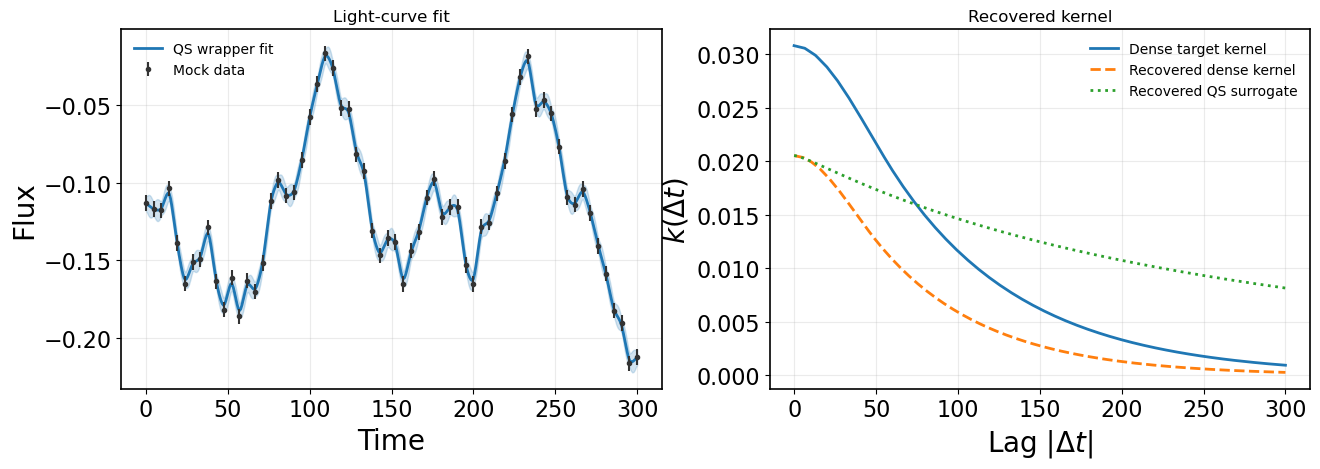

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

axes[0].fill_between(
    np.asarray(t_pred),
    np.asarray(mu_pred - std_pred),
    np.asarray(mu_pred + std_pred),
    color="tab:blue",
    alpha=0.2,
)
axes[0].plot(
    np.asarray(t_pred),
    np.asarray(mu_pred),
    color="tab:blue",
    lw=2,
    label="QS wrapper fit",
)
axes[0].errorbar(
    np.asarray(t_obs),
    np.asarray(y_obs),
    np.asarray(yerr),
    fmt=".",
    color="0.2",
    label="Mock data",
)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Flux")
axes[0].set_title("Light-curve fit")
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)

axes[1].plot(
    np.asarray(tau_grid), np.asarray(k_true), lw=2, label="Dense target kernel"
)
axes[1].plot(
    np.asarray(tau_grid),
    np.asarray(k_dense_best),
    lw=2,
    ls="--",
    label="Recovered dense kernel",
)
axes[1].plot(
    np.asarray(tau_grid),
    np.asarray(k_qs_best),
    lw=2,
    ls=":",
    label="Recovered QS surrogate",
)
axes[1].set_xlabel(r"Lag $|\Delta t|$")
axes[1].set_ylabel(r"$k(\Delta t)$")
axes[1].set_title("Recovered kernel")
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False)

### Notes

- The comparison sections still use dense convolved kernels only to evaluate approximation quality.
- The fitting section uses a hybrid quasiseparable wrapper: the physical parameters set a projected SHO expansion, and the optimizer is allowed to adjust that expansion with positive weight multipliers around the projection.
- Because the internal projection uses clipping and a ridge-regularized least-squares solve, a derivative-free optimizer is more robust here than the gradient-based dense-fit demo used previously.
- The right-hand recovery plot now shows both the dense kernel implied by the recovered physical parameters and the recovered QS surrogate actually used inside the model.
